# RandomForestClassifier — How it works

## What it is
**RandomForestClassifier** is an **ensemble learning method** that builds many decision trees and combines their predictions.

- Type: **Supervised learning**
- Task: **Classification**

---

## What it is used for

- Binary classification (e.g., spam vs not spam)
- Multi-class classification (e.g., image labels, customer segments)
- Works well on **tabular/structured data**

---

## Core idea

Instead of building one decision tree, Random Forest builds **many trees independently** and then combines them.

### Final prediction:
- Each tree makes a prediction
- The forest outputs the **majority vote**

\[
\hat{y} = \text{mode}(T_1(x), T_2(x), \dots, T_N(x))
\]

---

## How it works (step by step)

### 1. Bootstrap sampling (Bagging)
- From the dataset of size \(N\), randomly sample \(N\) points **with replacement**
- Each tree gets a slightly different dataset

### 2. Build decision trees
For each tree:

- At each split:
  - Randomly select a subset of features (not all features)
  - Choose the best split only from that subset

This introduces randomness and reduces correlation between trees.

---

## Why this works

- Individual trees are **high variance** (overfit easily)
- Averaging many trees:
  - reduces variance
  - improves generalization

---

## Loss / Splitting criteria

Random Forest does not optimize a global loss like boosting.  
Instead, each tree is built using **local impurity measures**.

### Common splitting criteria:

#### 1. Gini Impurity (default)

\[
G = 1 - \sum_{k=1}^{K} p_k^2
\]

- \(p_k\): proportion of class \(k\) in the node
- Lower is better (pure nodes)

---

#### 2. Entropy (Information Gain)

\[
H = -\sum_{k=1}^{K} p_k \log(p_k)
\]

- Measures disorder
- Trees choose splits that **reduce entropy**

---

### Key point:
- Random Forest does **not use gradient-based loss like XGBoost**
- It uses **greedy splitting based on impurity reduction**

---

## Important parameters

- `n_estimators`: number of trees
- `max_depth`: max depth of each tree
- `max_features`: number of features considered per split
- `min_samples_split`: minimum samples to split a node
- `min_samples_leaf`: minimum samples in a leaf

---

## When to use RandomForestClassifier

Use it when:

- You have **tabular data**
- You want a **strong baseline model**
- You want **less tuning compared to boosting**
- You want robustness to noise and overfitting

---

## Pros and Cons

### Pros
- Easy to use
- Less sensitive to hyperparameters
- Reduces overfitting compared to single trees
- Works well out of the box

### Cons
- Can be slower with many trees
- Less accurate than boosting (like XGBoost) in many cases
- Less interpretable than a single tree

---

## Intuition in one line

Random Forest = **many independent decision trees trained on random data + random features, combined by voting**

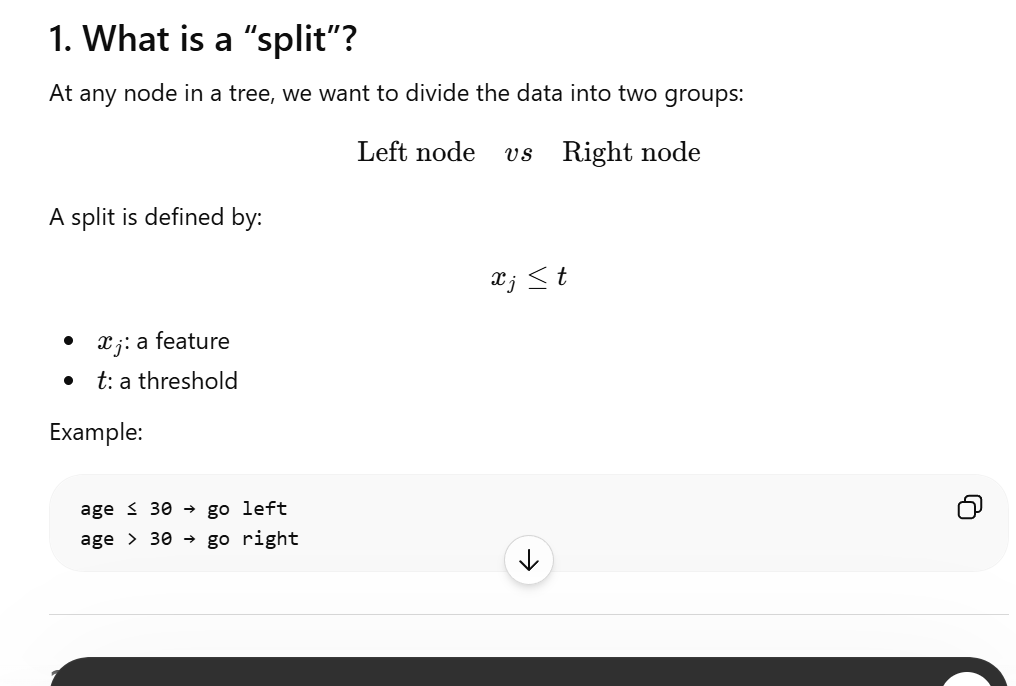

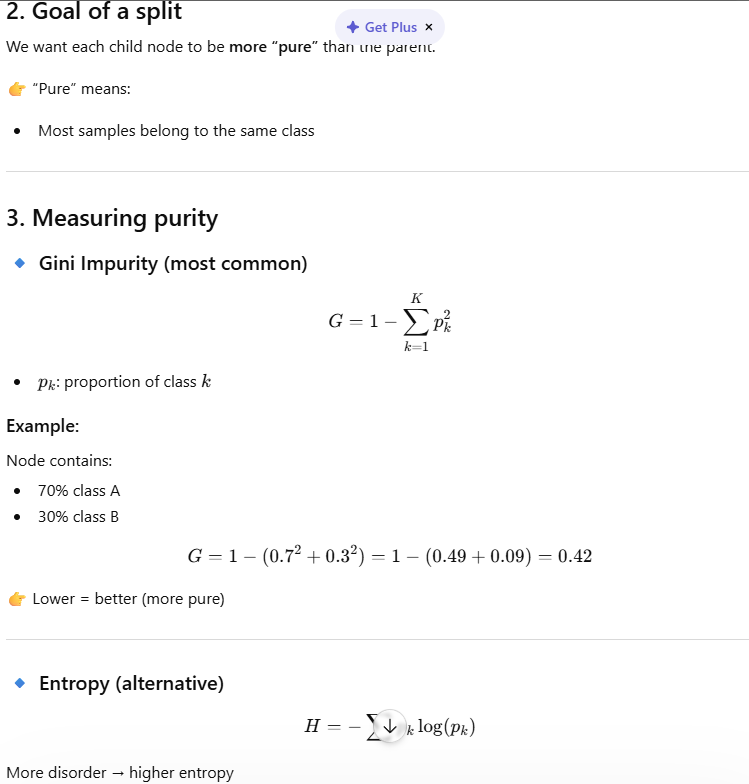

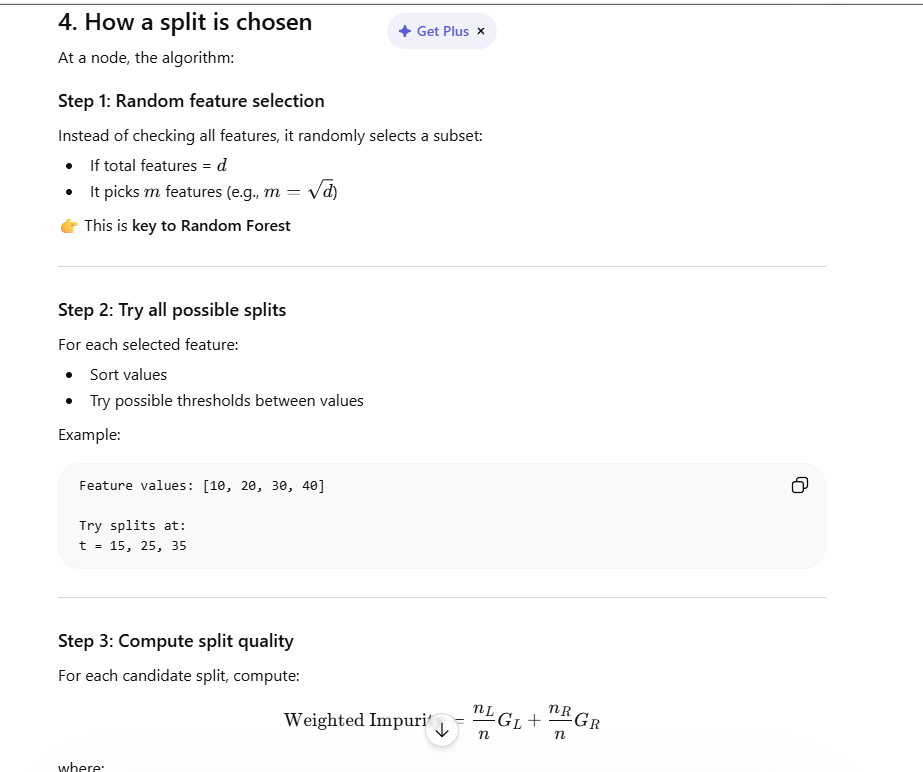

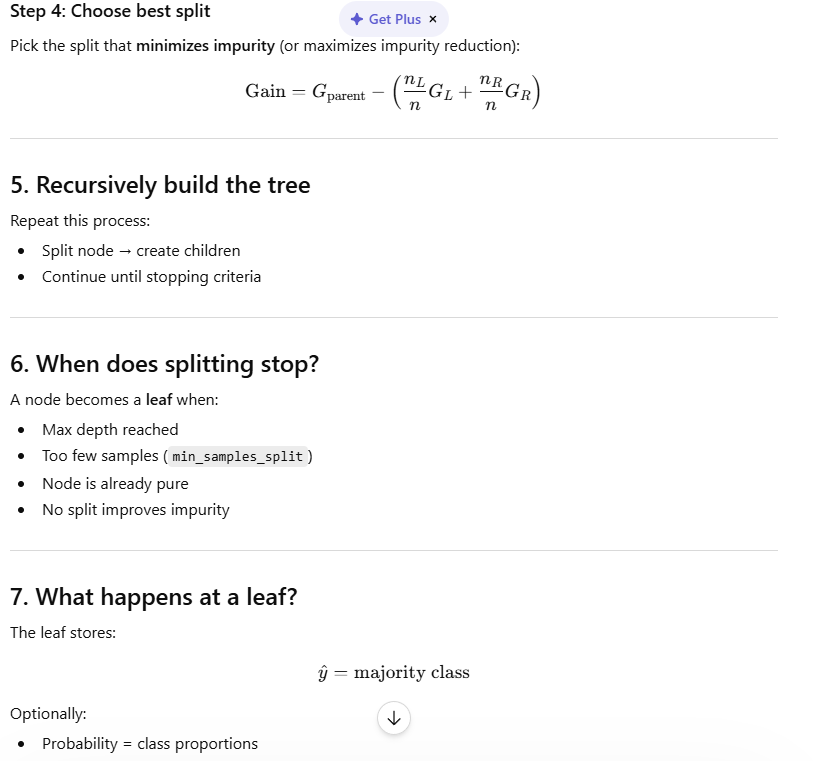

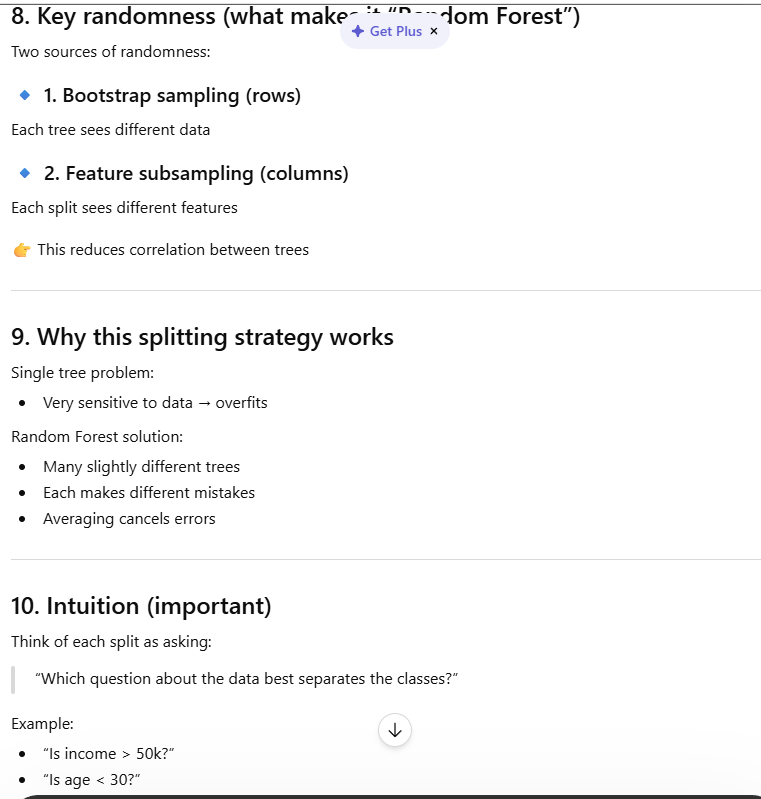

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('wine.csv')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.shape

(1599, 12)

In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


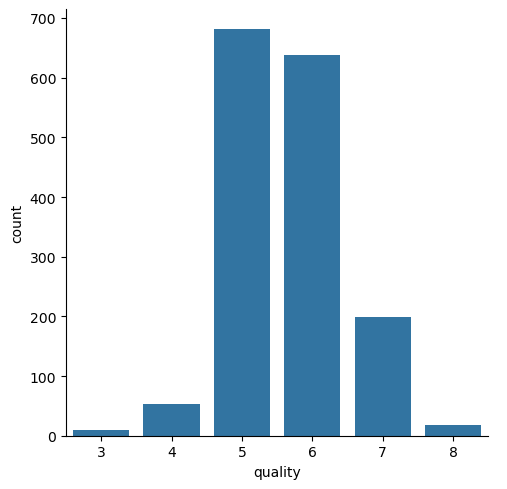

In [7]:
# number of values for each quality
sns.catplot(x='quality', data = df, kind = 'count')

In [8]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

<Axes: xlabel='quality', ylabel='volatile acidity'>

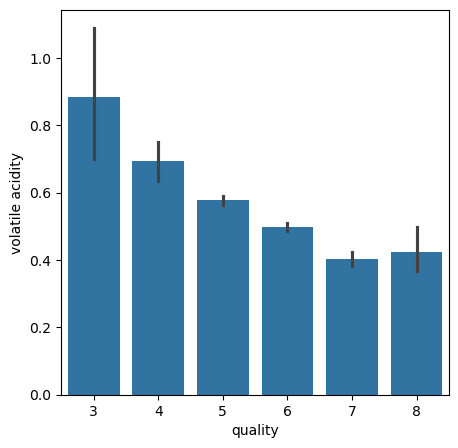

In [9]:
# volatile acidity vs Quality
plot = plt.figure(figsize=(5,5))
sns.barplot(x='quality', y = 'volatile acidity', data = df)

<Axes: xlabel='quality', ylabel='citric acid'>

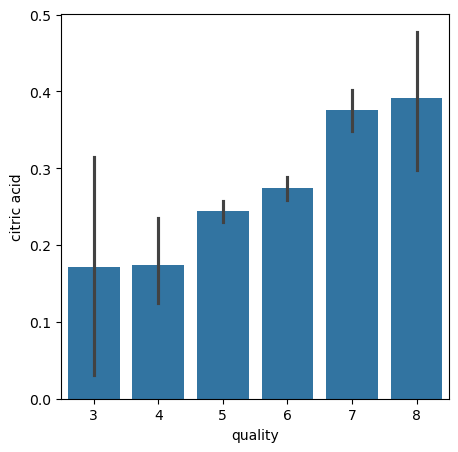

In [10]:
# citric acid vs Quality
plot = plt.figure(figsize=(5,5))
sns.barplot(x='quality', y = 'citric acid', data = df)

# Correlation

In [11]:
corr = df.corr()

<Axes: >

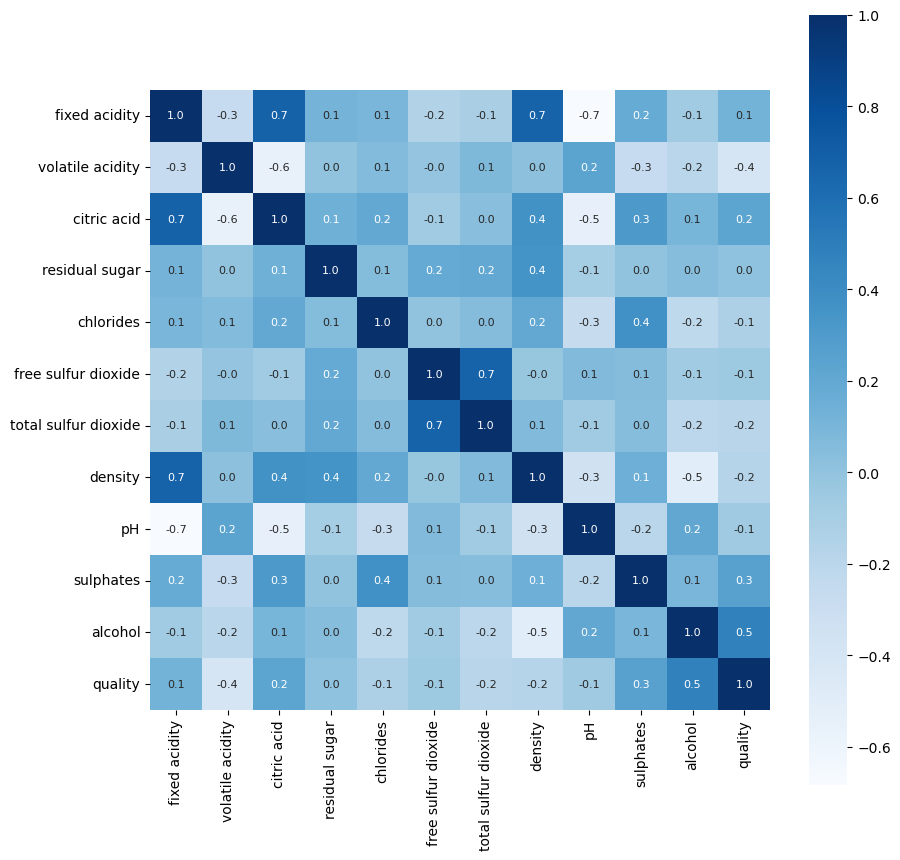

In [12]:
# constructing a heatmap to understand the correlation between the columns
plt.figure(figsize=(10,10))
sns.heatmap(corr, cbar=True, square=True, fmt = '.1f', annot = True, annot_kws={'size':8}, cmap = 'Blues')

# Data Preprocessing

In [13]:
X = df.drop('quality',axis=1)

In [14]:
Y = df['quality'].apply(lambda y_value: 1 if y_value>=8 else 0)

In [15]:
type(Y)

pandas.core.series.Series

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=3)

# Model Training

In [17]:
model = RandomForestClassifier()

In [18]:
model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Model Evaluation

In [19]:
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [20]:
print('Accuracy : ', test_data_accuracy)

Accuracy :  0.99375


# Prediction

In [21]:
input_data = (7.5,0.5,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.8,10.5)

# changing the input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the data as we are predicting the label for only one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]==1):
  print('Good Quality Wine')
else:
  print('Bad Quality Wine')

[0]
Bad Quality Wine


C:\Users\newta\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
